# L7 - Neural networks

### In this notebook, we'll build a simple neural network using TensorFlow/Scikit-Learn to classify the famous Iris dataset into one of three flower species: setosa, versicolor, or virginica.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

import seaborn as sns

In [2]:
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Adam Optimizer

Adam (short for **Adaptive Moment Estimation**) is one of the most popular and effective optimization algorithms used to train deep learning models. Adam adapts the learning rate for each parameter individually using **first** and **second moments** of the gradients:

- The **first moment** is the **mean** of the gradient (like momentum).
- The **second moment** is the **uncentered variance** of the gradient.

This helps Adam:
- Converge faster
- Handle sparse gradients
  
[Kingma & Ba (2014). *Adam: A Method for Stochastic Optimization*](https://arxiv.org/abs/1412.6980)

In [4]:
model = Sequential([
    Input(shape=(4,)),
    Dense(10, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [5]:
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, verbose=0)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9333


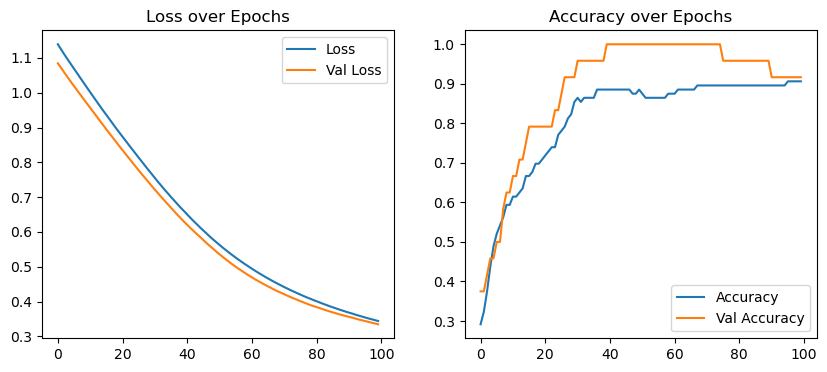

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()

In [7]:
model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=1000)

model.fit(X_train_scaled, y_train)

d:\Info\AnacondaFolder\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

In [8]:
y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9666666666666667


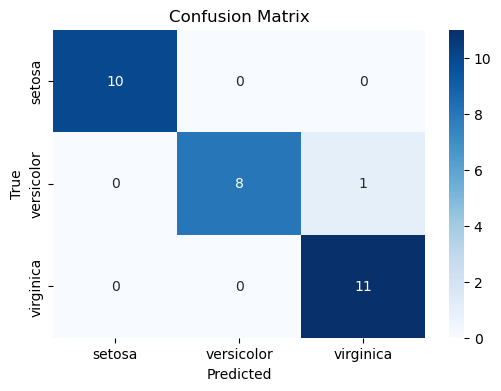

In [9]:
y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()